# Prediccion y Riesgo de ACV

## Sobre el dataset

Este notebook es el punto de partida del trabajo práctico: predecir el riesgo de que un paciente sufra un Accidente Cerebrovascular (ACV / *stroke*) a partir de datos demográficos y clínicos (edad, hipertensión, enfermedad cardíaca, nivel de glucosa, BMI, hábito de fumar, etc.). No buscamos solo clasificar sí/no, sino entregar un score de riesgo que después se pueda calibrar.

Los datos vienen del [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) de Kaggle (autor: fedesoriano). El archivo original (`data/healthcare-dataset-stroke-data.csv`) pesa alrededor de 315 KB y tiene 5110 registros de pacientes con 12 columnas: `id`, `gender`, `age`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status` y la variable objetivo `stroke`.

Un punto que va a condicionar buena parte del preprocesamiento: la clase positiva (`stroke = 1`) es apenas ~5% de los registros, un desbalance fuerte que se retoma más abajo al analizar frecuencias y al preparar los datos para el entrenamiento.

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
raw.shape

(5110, 12)

Se observan un total de 5110 registros de pacientes.

In [4]:
categorical = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status", "stroke"]
numeric = ["age", "avg_glucose_level", "bmi"]

## Nulos

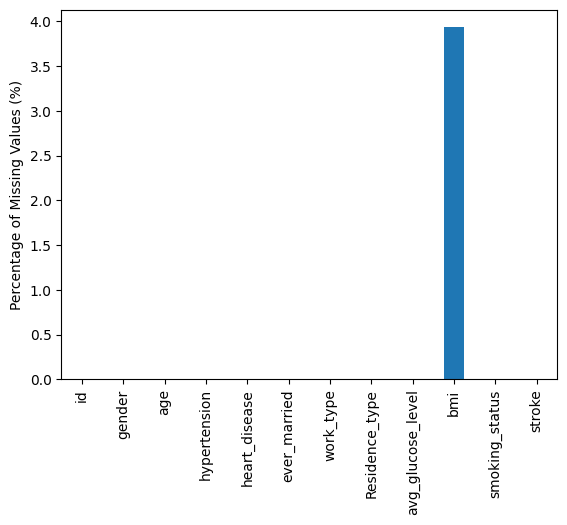

In [5]:
raw.isnull().mean().mul(100).plot(kind='bar')
plt.ylabel('Percentage of Missing Values (%)')
plt.show()

Observamos que la unica feature que presenta valores nulos es BMI.

## Frecuencias y Distribuciones

In [6]:
def plot_categorical_distributions(df, features, figsize=(12, 5)):
    for feature in features:
        plt.figure(figsize=figsize)
        sns.countplot(x=feature, data=df, palette="pastel", hue=feature, legend=False)
        plt.title(f"Frecuencias de {feature}", fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel("Count", fontsize=12)
        plt.xticks(rotation=30)  # rotate labels if needed
        plt.tight_layout()
        plt.show()

def plot_numerical_densities(df, features, figsize=(12, 5)):
    for feature in features:
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # KDE plot
        sns.kdeplot(data=df, x=feature, fill=True, palette="pastel", hue=2, alpha=0.5, ax=axes[0], legend=False)
        axes[0].set_title(f"Densidad de {feature}", fontsize=14)
        axes[0].set_xlabel(feature, fontsize=12)
        axes[0].set_ylabel("Densidad", fontsize=12)

        # Boxplot
        sns.boxplot(data=df, x=feature, palette="pastel", hue=20, ax=axes[1], legend=False)
        axes[1].set_title(f"Boxplot de {feature}", fontsize=14)
        axes[1].set_xlabel(feature, fontsize=12)

        plt.tight_layout()
        plt.show()


### Categoricas

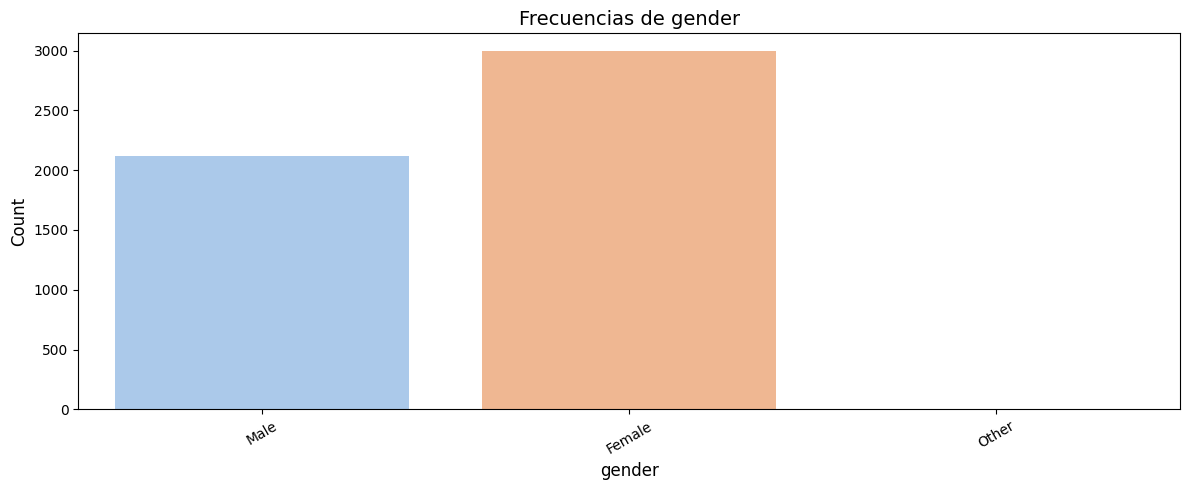

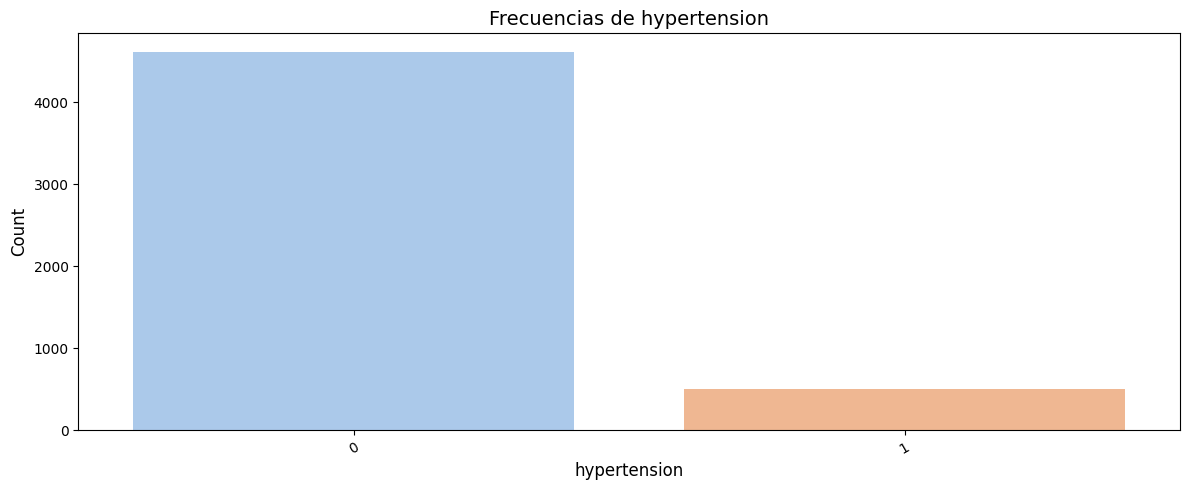

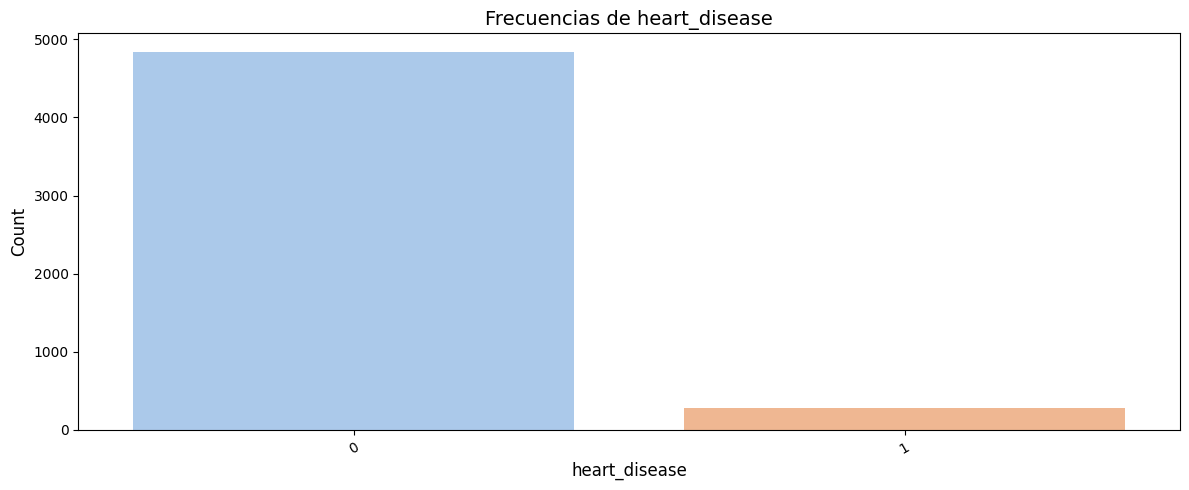

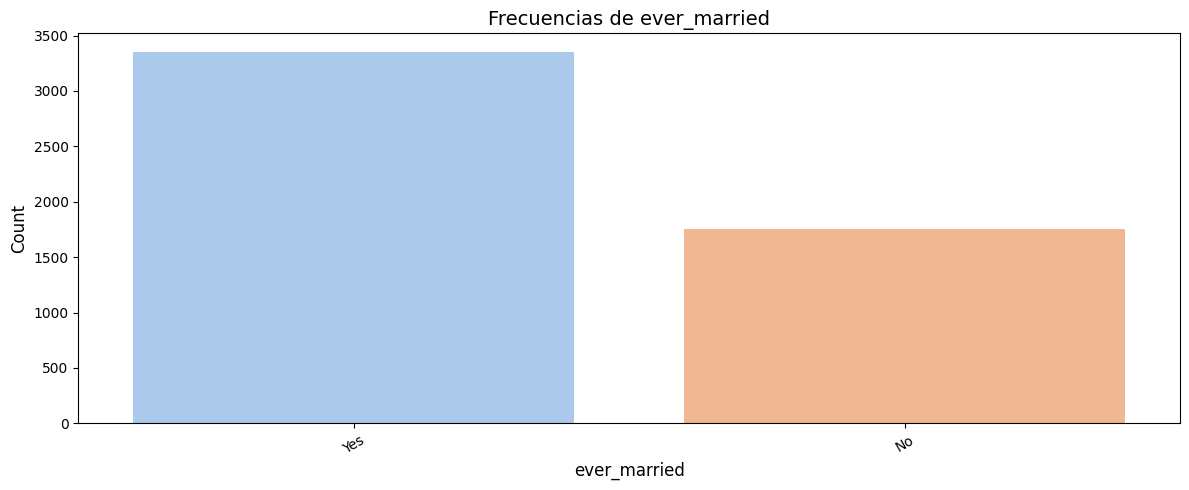

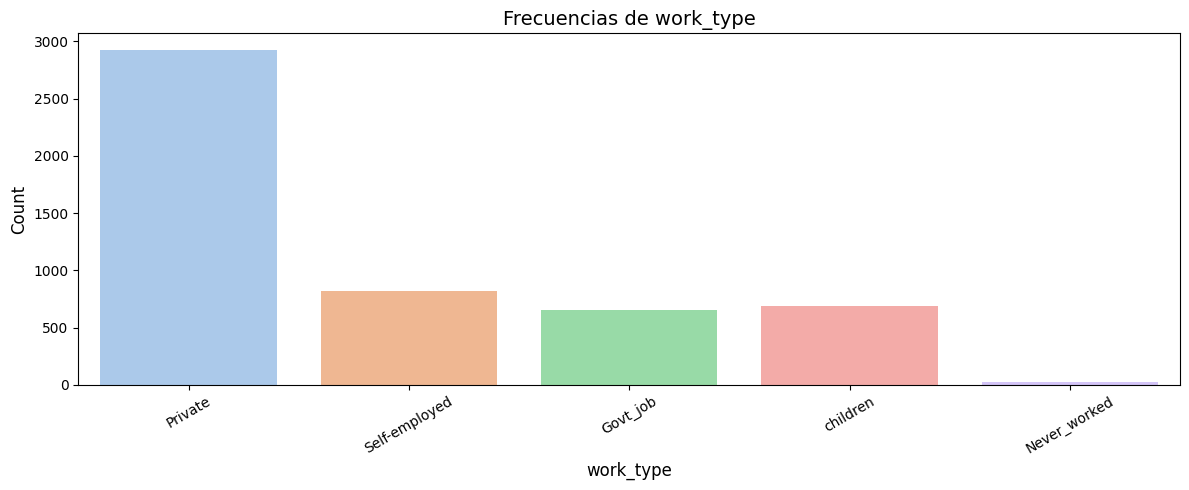

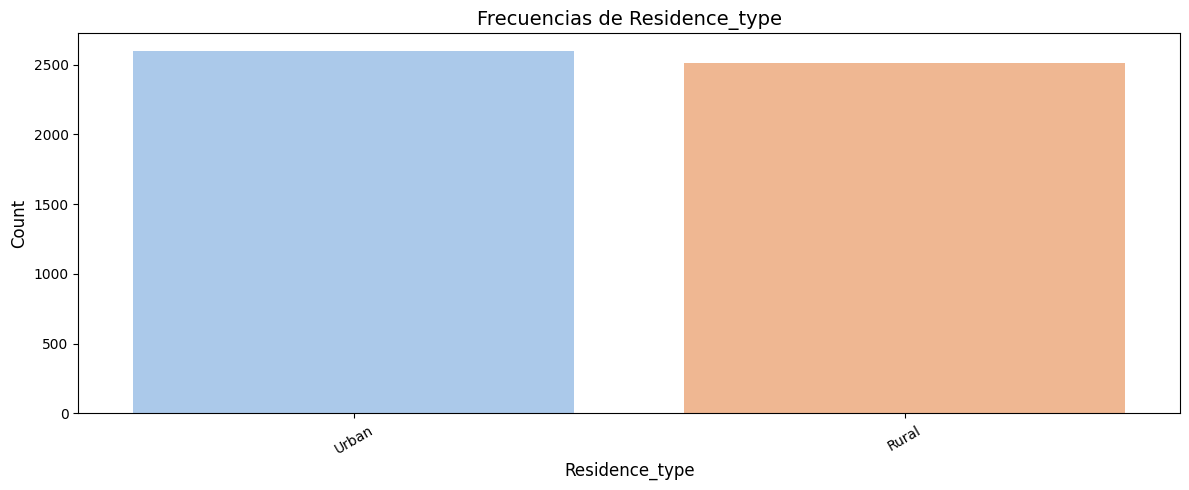

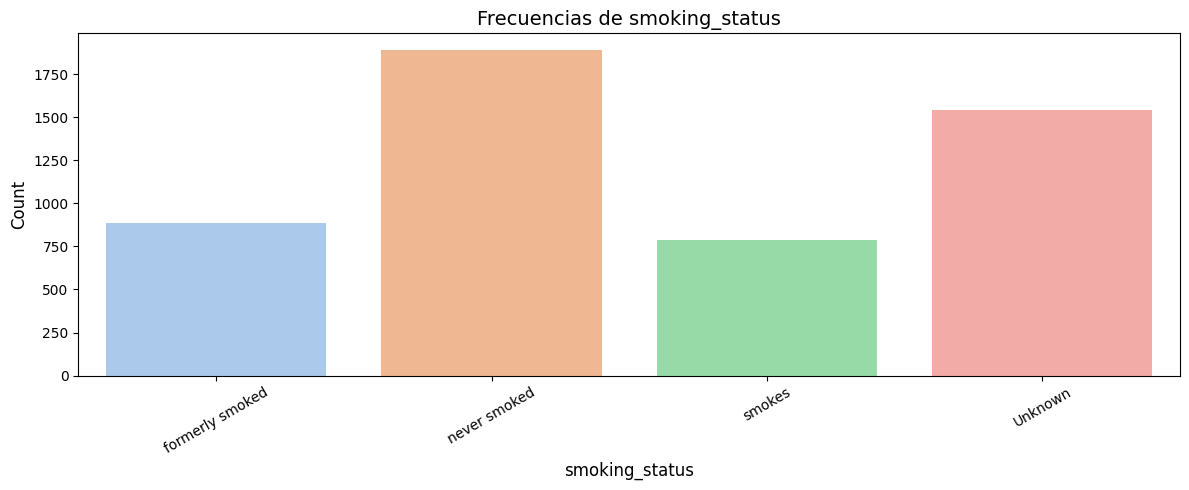

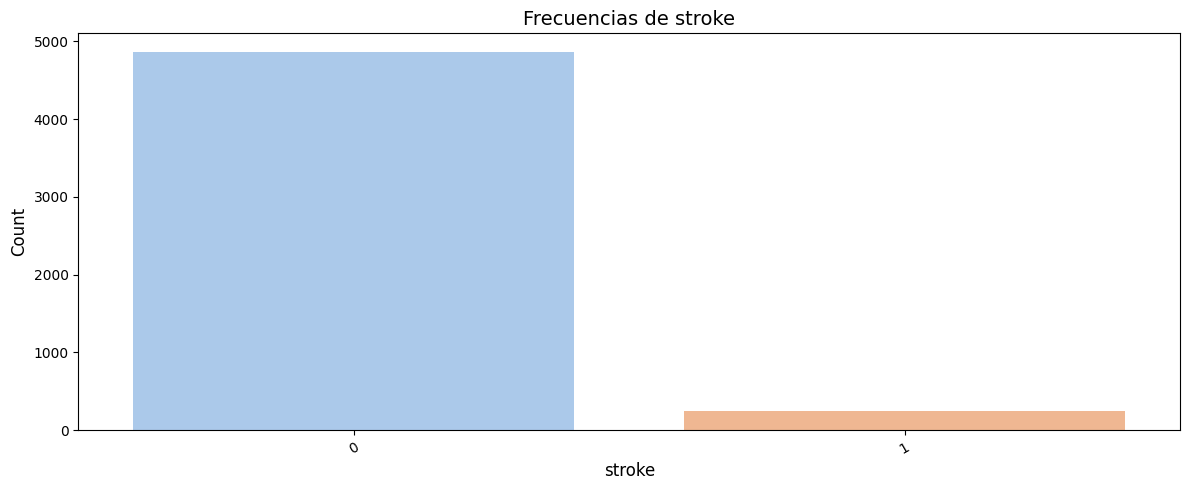

In [7]:
plot_categorical_distributions(raw, categorical)

#### Observaciones:

1) No se observan outliers.
2) La feature `smoking_status` presenta un posible valor "Unknown". Este valor podriamos considerarlo como un valor nulo o dato faltante e imputarlo apropiadamente a alguno de los demas valores posibles. Pero, por otro lado, este valor podria cargar con informacion adicional de utilidad para nuestro modelo. Los pacientes que decidieron no aportar este dato podrian tener algun tipo de correlacion con nuestra variable target.
3) Se observa que nuestra variable target `stroke` presenta un gran desbalance, por lo que sera necesario balancear los datos antes del entrenamiento. Debido al alto grado de desbalance, utilizaremos un metodo de **oversampling**.

### Numericas

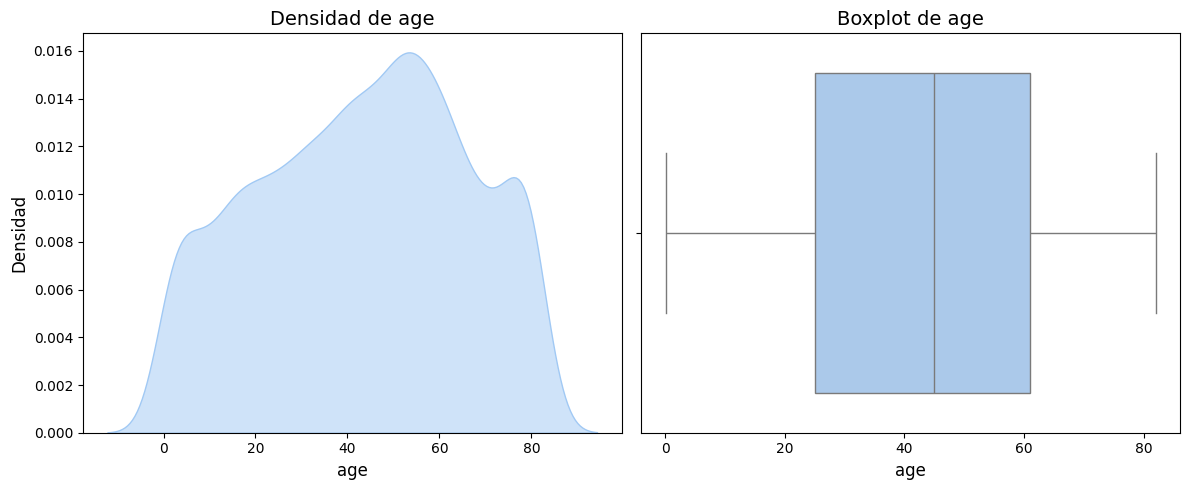

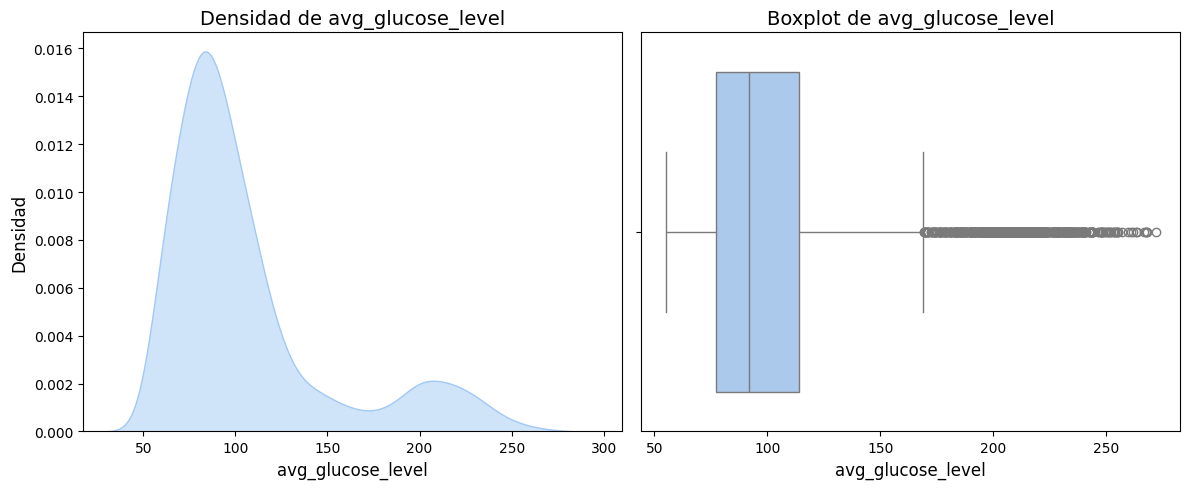

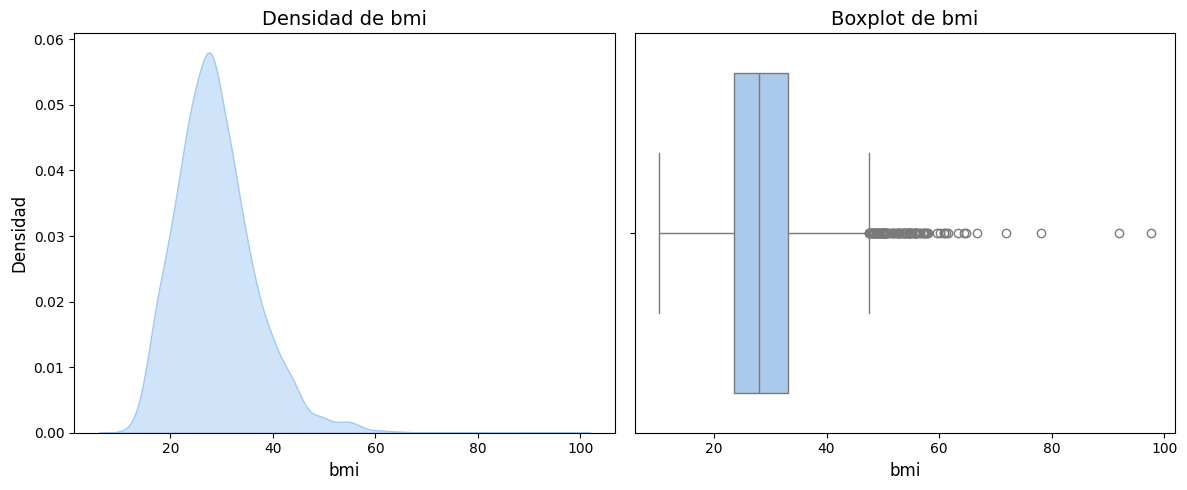

In [8]:
plot_numerical_densities(raw, numeric)

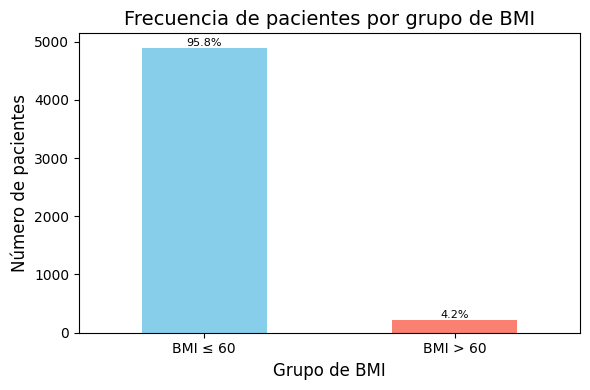

In [9]:
# Create groups
data = raw.copy()
data["bmi_group"] = data["bmi"].apply(lambda x: "BMI ≤ 60" if x <= 60 else "BMI > 60")

# Count frequencies
counts = data["bmi_group"].value_counts()
percentages = counts / counts.sum() * 100

# Plot
plt.figure(figsize=(6, 4))
ax = counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Frecuencia de pacientes por grupo de BMI", fontsize=14)
plt.xlabel("Grupo de BMI", fontsize=12)
plt.ylabel("Número de pacientes", fontsize=12)
plt.xticks(rotation=0)

# Count labels
for i, value in enumerate(counts):
    ax.text(i, value + 0.5, f"{percentages.iloc[i]:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

#### Observaciones:

1) No se observan outliers en el feature `age`.
2) En el feature `avg_glucose_level` se observa un pequeño subgrupo de los pacientes que presenta niveles de glucosa promedios mas elevados de lo normal (alrededor de 210 mg/dL). Del *box plot*, estos datos podrian interpretarse como outliers, pero, aunque extremos, son valores posibles para un grupo de pacientes con diabetes o hiperglucemia. Es por ello que no descartaremos este feature y derivaremos un nuevo feature binario `high_glucose_level` a partir de los *126 mg/dL* que podria mostrar algun tipo de correlacion con nuestro target y aportar informacion a nuestro modelo.
3) El feature `bmi` tambien presenta varios puntos de interes que podriamos interpretar como outliers. Del *box plot* se observa que existen algunos pacientes con BMI's por encima de 60. Un BMI entre 50 y 60 representa casos extremos de pacientes con *obesidad morbida*, por lo que valores por encima de 60 son practicamente imposibles. Es por eso que trataremos a los valores mayores a 60 de bmi como outliers y, debido a so bajo numero (cercano al 4%), los eliminaremos de nuestro dataset. Por otro lado, y siguendo el mismo criterio utilizado para `avg_glucose_level`, crearemos una nueva feature binaria `high_bmi` indicando con un 1 (true) los pacientes con un BMI mayor a 30 (a partir del cual se considera obesidad de grado 1).

## Pre-procesamiento

### Recorte

Primero eliminaremos las observaciones mencionadas anteriormente relacionadas con valores nulos y outliers.

In [10]:
preprocessed = raw.copy()
preprocessed = preprocessed[(preprocessed["bmi"].notna()) & (preprocessed["bmi"] <= 60)]
preprocessed = preprocessed.drop(columns=["id"])  ## Eliminamos la columna ID ya que no aporta informacion
preprocessed.shape

(4896, 11)

### Feature Engineering

Añadimos las nuevas features descriptas anteriormente.

In [11]:
preprocessed["high_glucose_level"] = (preprocessed["avg_glucose_level"] > 126).astype(int)
preprocessed["high_bmi"] = (preprocessed["bmi"] > 30).astype(int)
preprocessed.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,high_glucose_level,high_bmi
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,1,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,1,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,1,0
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,1,0


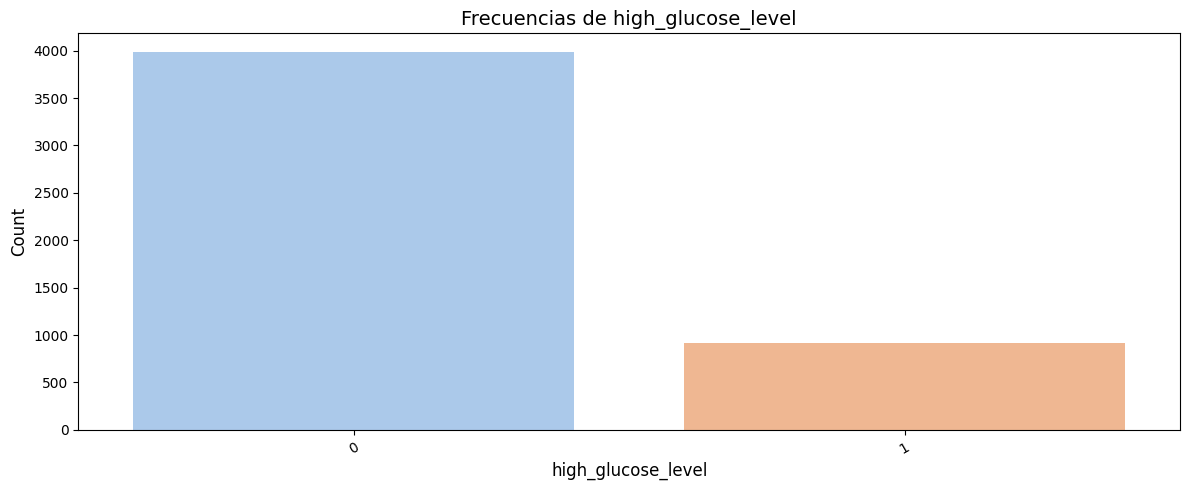

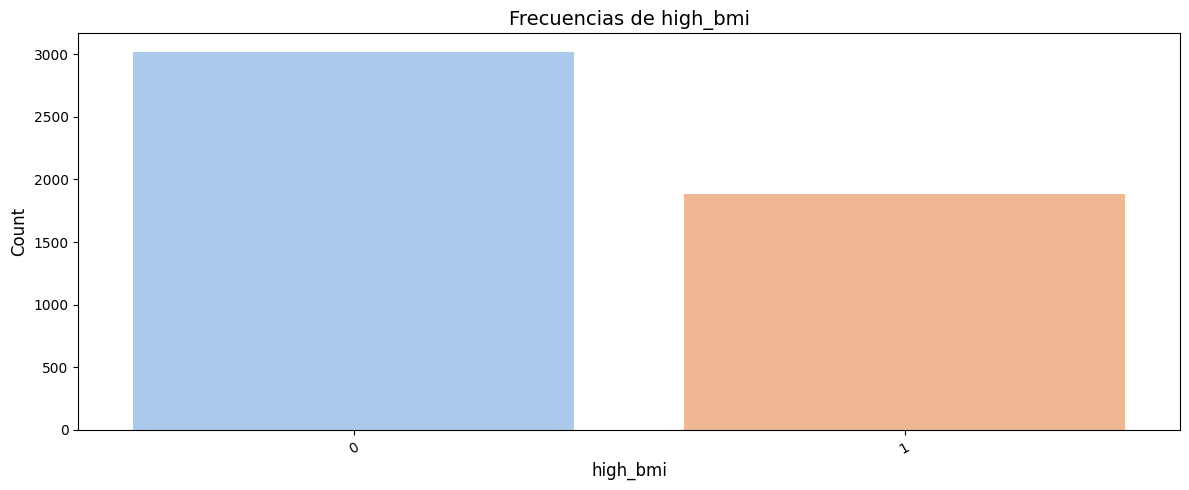

In [12]:
plot_categorical_distributions(preprocessed, ["high_glucose_level", "high_bmi"])

### Split del Dataset

In [13]:
from sklearn.model_selection import train_test_split

X = preprocessed.drop(columns=["stroke"])
y = preprocessed["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% para test
    stratify=y              # estratificación por la variable target
)

### Codificacion

Para la codificacion de nuestras variables categoricas con valores de texto a numericas utilizaremos *label encoding*.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder

binary_features = ["ever_married"]
target_features = ["gender", "smoking_status", "work_type", "Residence_type"]

binary_encoder = OrdinalEncoder()
target_encoder = TargetEncoder()

binary_encoder.fit(X_train[binary_features])
target_encoder.fit(X_train[target_features], y_train)

def encode(df):
    result = df.copy()
    result[binary_features] = binary_encoder.transform(result[binary_features])
    result[target_features] = target_encoder.transform(result[target_features])
    return result

X_train_encoded = encode(X_train)
X_train_encoded.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,high_glucose_level,high_bmi
4900,0.042357,7.0,0,0,0.0,0.001873,0.046004,77.12,18.6,0.021142,0,0
4642,0.042870,63.0,1,0,1.0,0.045595,0.046004,62.13,23.6,0.044037,0,0
782,0.042870,38.0,1,0,1.0,0.070189,0.046004,91.00,33.3,0.044037,0,1
859,0.042357,43.0,0,0,1.0,0.045595,0.046004,135.75,35.9,0.055342,1,1
3485,0.042357,39.0,1,0,1.0,0.070189,0.046004,71.66,28.7,0.044037,0,0


In [15]:
X_test_encoded = encode(X_test)

### Estandarizacion

In [16]:
from sklearn.preprocessing import StandardScaler

all_features = X_train_encoded.columns.tolist()
scaler = StandardScaler()
scaler.fit(X_train_encoded)

def scale(df):
    result = df.copy()
    result[all_features] = scaler.transform(result[all_features])
    return result

X_train_scaled = scale(X_train_encoded)
X_train_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,high_glucose_level,high_bmi
4900,-0.396429,-1.595325,-0.322057,-0.235034,-1.381015,-2.153842,0.989837,-0.633854,-1.350692,-1.330129,-0.474638,-0.787947
4642,0.308162,0.875546,3.105045,-0.235034,0.724105,0.156453,0.989837,-0.970167,-0.689361,0.086793,-0.474638,-0.787947
782,0.308162,-0.227521,3.105045,-0.235034,0.724105,1.455995,0.989837,-0.322445,0.593620,0.086793,-0.474638,1.269120
859,-0.396429,-0.006908,-0.322057,-0.235034,0.724105,0.156453,0.989837,0.681556,0.937512,0.786425,2.106867,1.269120
3485,-0.396429,-0.183399,3.105045,-0.235034,0.724105,1.455995,0.989837,-0.756354,-0.014804,0.086793,-0.474638,-0.787947


In [17]:
X_test_scaled = scale(X_test_encoded)

### Balanceo de los Datos de Entrenamiento

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

proportions = y_train_balanced.value_counts(normalize=True)  # relative frequencies
print(proportions)

stroke
0    0.5
1    0.5
Name: proportion, dtype: float64


## Reduccion de Dimencionalidad

### Analisis de Correlacion

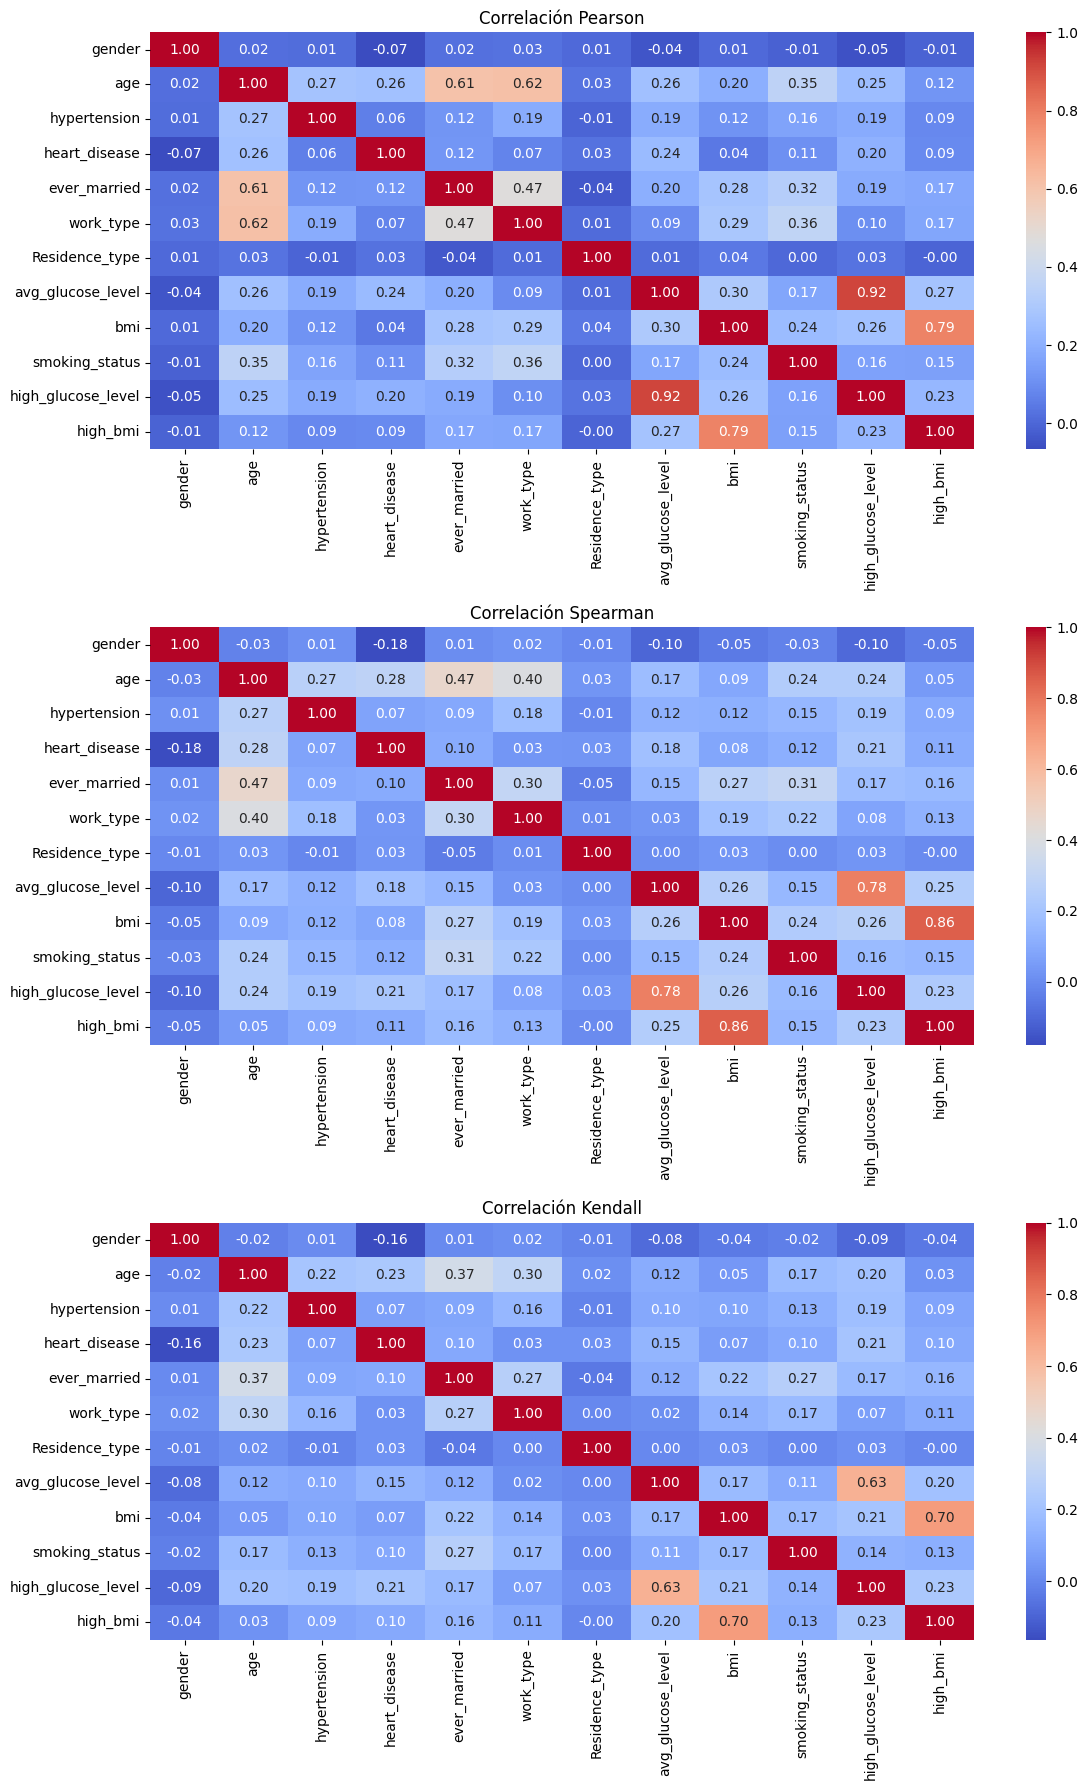

In [19]:
# Calcular las tres matrices de correlación
corr_pearson = X_train_balanced.corr(method="pearson")
corr_spearman = X_train_balanced.corr(method="spearman")
corr_kendall = X_train_balanced.corr(method="kendall")

# Crear la figura con subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Pearson
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Correlación Pearson")

# Spearman
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Correlación Spearman")

# Kendall
sns.heatmap(corr_kendall, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[2])
axes[2].set_title("Correlación Kendall")

plt.tight_layout()
plt.show()

No se observan correlaciones significativas entre las features mas alla de aquellas que derivamos como `high_glucose_level` y `high_bmi` con sus respectivas features de origen.

### Análisis de componentes principales (PCA)

In [20]:
from sklearn.decomposition import PCA

n_components = X_train_balanced.shape[1]
pca = PCA(n_components=n_components)
pca.fit(X_train_balanced)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",12
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD

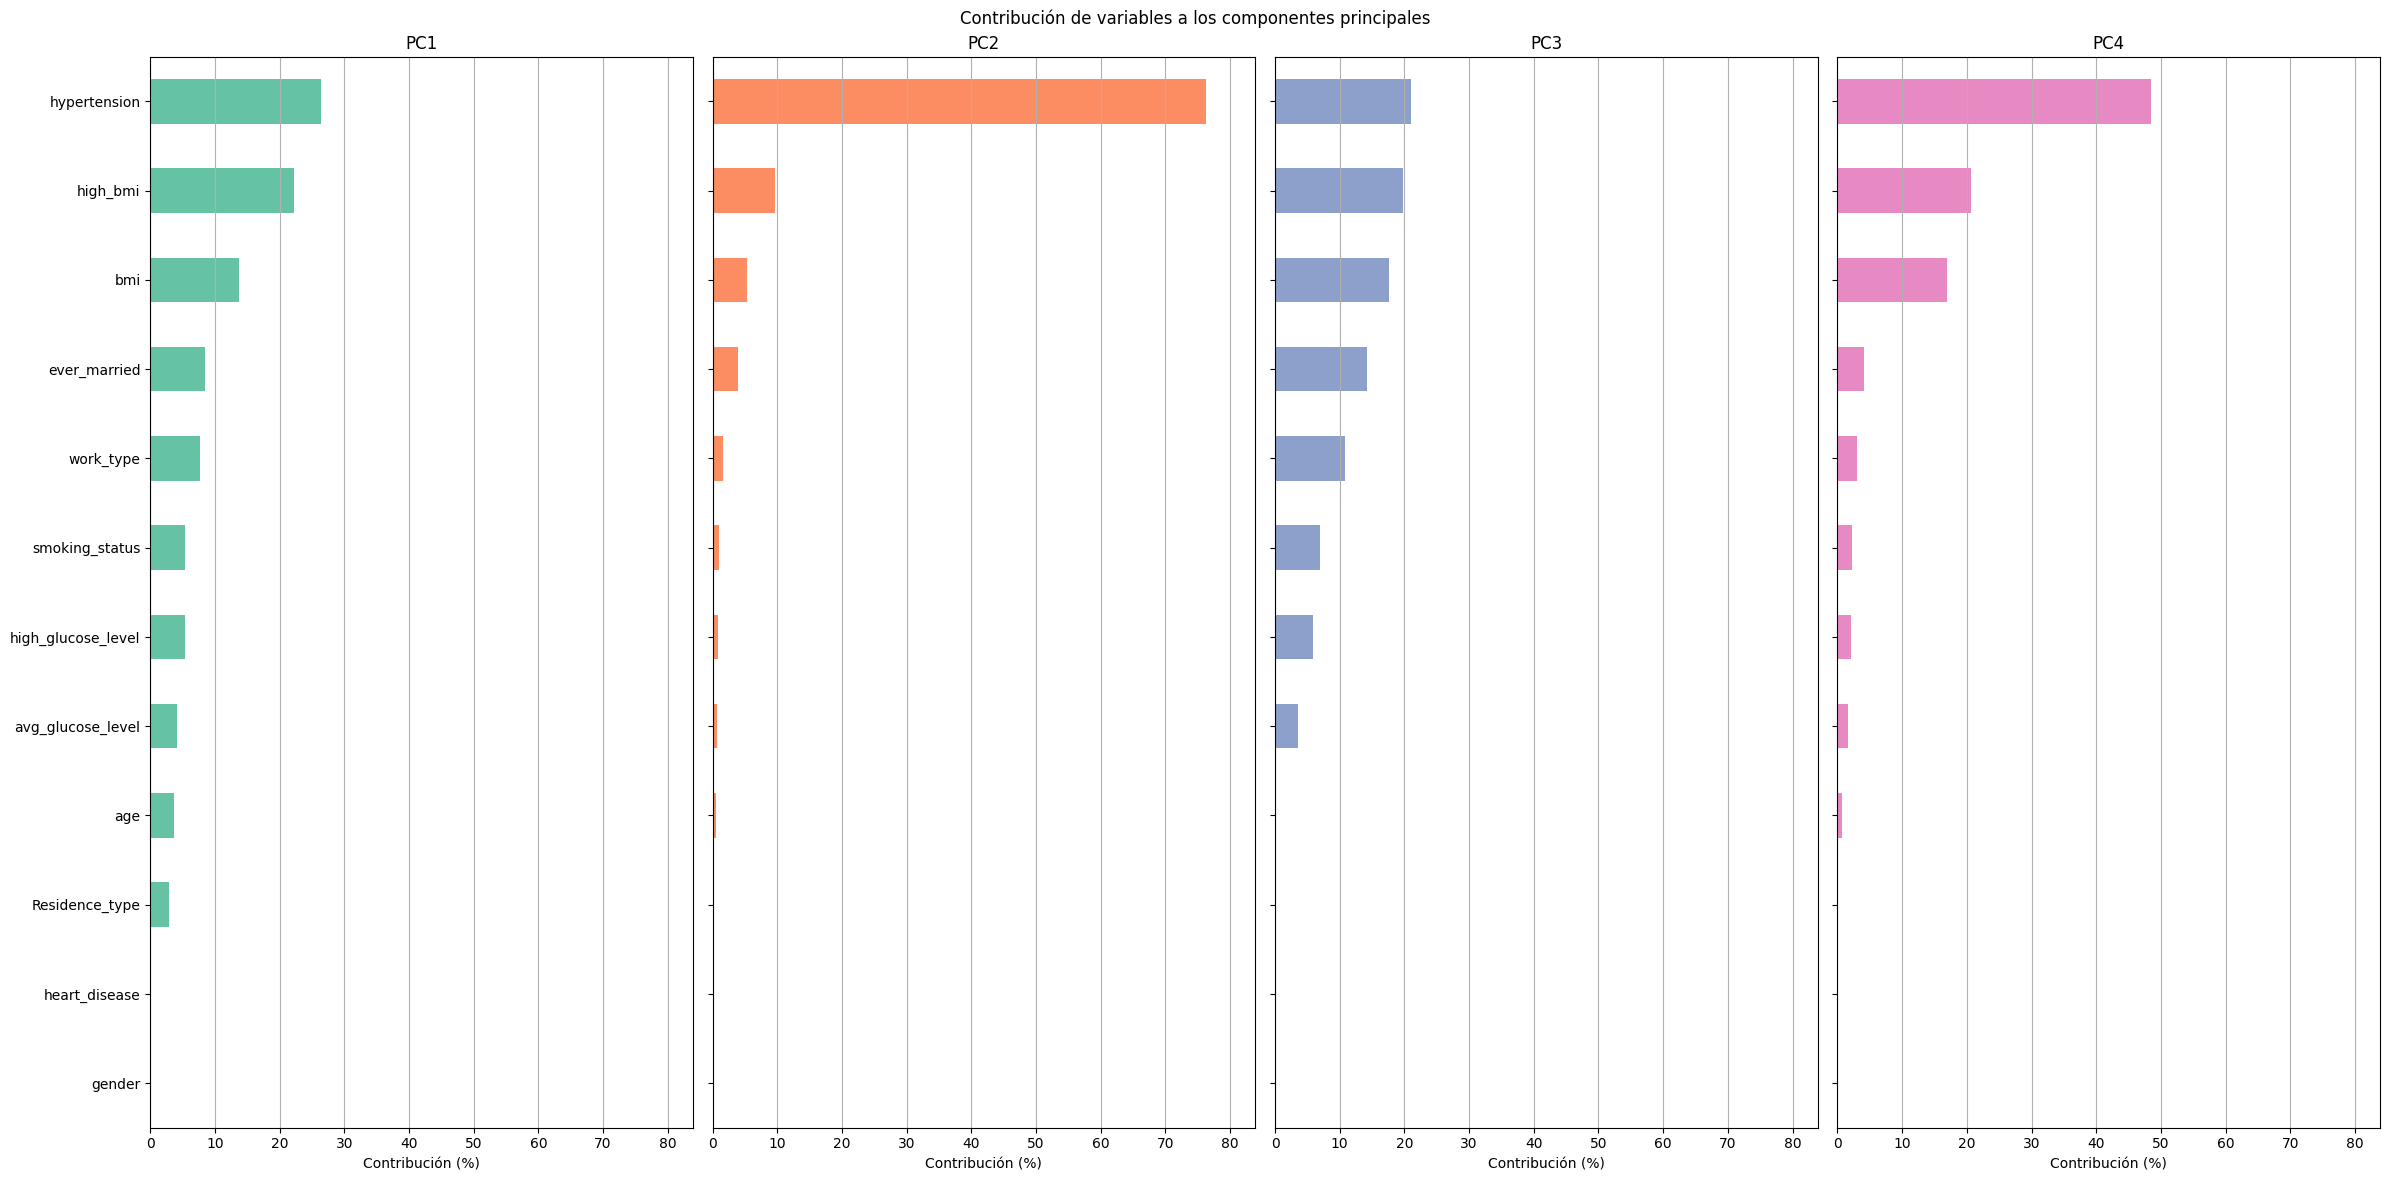

In [21]:
feature_names = X_train_balanced.columns.tolist()

# Definir número de componentes a graficar
pc_number = 4

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)

contrib = (loadings**2)
contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

# Crear subplots dinámicamente según n_components
fig, ax = plt.subplots(1, pc_number, figsize=(6*pc_number, 12), sharey=True)

# Si n_components = 1, ax no es iterable, lo convertimos en lista
if pc_number == 1:
    ax = [ax]

# Graficar cada componente
for i in range(pc_number):
    pc = f"PC{i+1}"
    contrib[pc].sort_values().plot.barh(ax=ax[i], color=plt.cm.Set2(i))
    ax[i].set_title(pc)
    ax[i].set_xlabel("Contribución (%)")
    ax[i].grid(axis='x')

# Ajustar límites de los ejes para que sean consistentes
max_val = contrib[[f"PC{i+1}" for i in range(pc_number)]].max().max()
for i in range(pc_number):
    ax[i].set_xlim(0, max_val * 1.1)

plt.suptitle("Contribución de variables a los componentes principales")
plt.tight_layout()
plt.show()

Una observacion interesante de este analisis es que `hypertension` y `high_bmi` son constantemente las features que mayor informacion contribuyen a cada componente. 

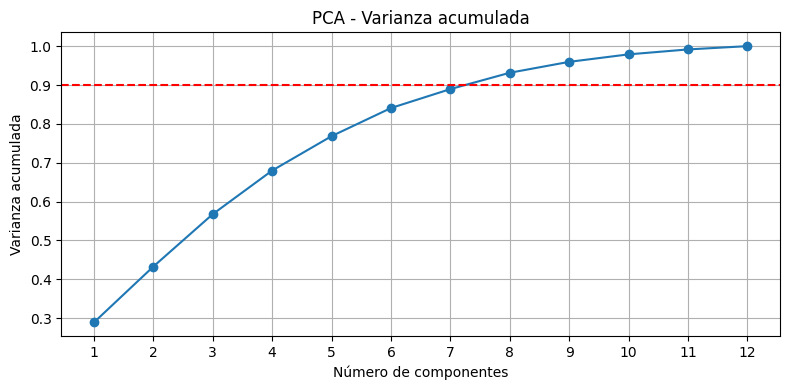

In [22]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(8, 4))
plt.plot(components, cumulative_var, marker='o')
plt.xticks(components)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% de varianza')
plt.tight_layout()
plt.show()

Para poder explicar por lo menos el 90% de la varianza, este analisis revela que necesitariamos, por lo menos, 7 componentes. 

Consideramos que esta reduccion de dimensionalidad no seria lo suficientemente significativa, y, considerando que utilizar componentes principales para entrenar nuestro modelo significaria una perdida en la interpretabilidad de los datos, optamos con quedarnos con las features originales para el entrenamiento.

## Guardamos los datos listos para el entrenamiento

Guardamos dos versiones del set de entrenamiento: la balanceada con SMOTE (`X_train_final`/`y_train_final`, para comparaciones rápidas) y la original sin balancear (`X_train_raw`/`y_train_raw`). Esta última la vamos a necesitar en `modeling.ipynb` para armar un `Pipeline` que aplique SMOTE *dentro* de cada fold de validación cruzada al ajustar hiperparámetros — si tuneáramos directamente sobre el train ya balanceado, las muestras sintéticas de SMOTE podrían quedar repartidas entre el fold de entrenamiento y el de validación de un mismo split (por ser interpolaciones de vecinos reales), inflando artificialmente el score de esa validación cruzada.

In [ ]:
from pathlib import Path

X_train_final, y_train_final = X_train_balanced, y_train_balanced
X_test_final, y_test_final = X_test_scaled, y_test

# Guardar datasets en un único archivo
datasets = {
    "X_train_final": X_train_final,
    "y_train_final": y_train_final,
    "X_train_raw": X_train_scaled,  # sin balancear, para tuning con Pipeline(SMOTE + modelo)
    "y_train_raw": y_train,
    "X_test_final": X_test_final,
    "y_test_final": y_test_final
}

# Exportar a archivo pickle
datasets_file = Path("../data/preprocessed.pkl").resolve()
pd.to_pickle(datasets, datasets_file)

print(f"Datasets guardados en {datasets_file}")